# Building Blocks Of Geopandas

If you have ever used Uber to see how close your driver is, used Google Maps to get somewhere, or checked the exact temperature of your location, you are already a beneficiary of Geospatial Analysis! Today, a considerable amount of data generated has a spatial component to it. Outside the rather complex use case of geospatial analysis in a ride sharing app like Uber, geospatial data especially when combined with traditional datasets-such as sales data, can unlock even deeper insights. For example, sales data combined with the store locations can reveal regional purchasing trends or health records combined with hospital locations can reveal gaps in healthcare coverage. In short, geospatial analysis, helps us uncover where things happen and why they happen there , making it a key skill to have as a Data Analyst.


### Types of Spatial Data

Spatial data can be broadly categorized into two types:

-   **Vector Data**  Vector data describes features on the Earth's surface using discrete geometries such as points, lines and polygons. Points represent features such as the exact location of a hospital, school, building etc. Lines are used to represent linear features such as roads, rivers, and rail lines. Lastly, polygons represent areas like the boundaries of a country, farm parcels or lakes.
    
-   **Raster Data**  Raster Data on the other hand represents geographical phenomena as a grid of cells, where each cell holds a specific value.Each cell holds information, often related to continuous phenomena like elevation, temperature, or land cover.


### File formats for Vector Data

Some of the most common vector data formats are:

-   **Shapefile**  Shapefiles are the most common vector data format. It comprises three files that are usually provided in a zip file:

> > -   The .shp file contains shape geometry.
> > -   The .dbf file holds attributes for each geometry,
> > -   The .shx file or shape index file helps link the attributes to the shapes.

-   **GeoJSON**  It’s a newer format for geospatial data released in 2016. Unlike shapefiles, GeoJSON is a single file, making it easier to work with.
    
-   **KMZ/KML files**  This is the file format used for Google Earth Engine.
    
-   **OSM .XML file**  This is the native XML file used by the Open Street Map library.

In [1]:
# installing geopandas
!pip3 install geopandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.7/24.7 MB 3.6 MB/s  0:00:06 eta 0:00:010:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 2.6 MB/s  0:00:012.6 MB/s eta 0:00:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 4.9 MB/s  0:00:00m 32.3 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [geopandas]━ 3/4 [geopandas]

[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: pip3 install --upgrade pip


In [7]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt

In [11]:
# loading the shapefile
world = gpd.read_file('./world_countries/ne_10m_admin_0_countries.shp')
world.head()

,featurecla,scalerank,LABELRANK,SOVEREIGNT,SOV_A3,ADM0_DIF,LEVEL,TYPE,TLC,ADMIN,...,FCLASS_TR,FCLASS_ID,FCLASS_PL,FCLASS_GR,FCLASS_IT,FCLASS_NL,FCLASS_SE,FCLASS_BD,FCLASS_UA,geometry
0,Admin-0 country,0,2,Indonesia,IDN,0,2,Sovereign country,1,Indonesia,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((117.70361 4.16341, 117.70361 4..."
1,Admin-0 country,0,3,Malaysia,MYS,0,2,Sovereign country,1,Malaysia,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((117.70361 4.16341, 117.69711 4..."
2,Admin-0 country,0,2,Chile,CHL,0,2,Sovereign country,1,Chile,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((-69.51009 -17.50659, -69.50611..."
3,Admin-0 country,0,3,Bolivia,BOL,0,2,Sovereign country,1,Bolivia,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((-69.51009 -17.50659, -69.51009 -17.5..."
4,Admin-0 country,0,2,Peru,PER,0,2,Sovereign country,1,Peru,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((-69.51009 -17.50659, -69.63832..."


<Axes: >

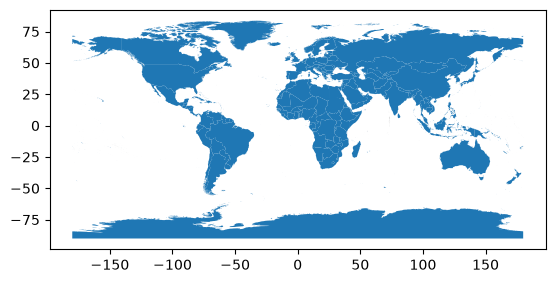

In [12]:
world.plot()

In [13]:
print(type(world))

<class 'geopandas.geodataframe.GeoDataFrame'>


In [15]:
print(world.columns)

Index(['featurecla', 'scalerank', 'LABELRANK', 'SOVEREIGNT', 'SOV_A3',
       'ADM0_DIF', 'LEVEL', 'TYPE', 'TLC', 'ADMIN',
       ...
       'FCLASS_TR', 'FCLASS_ID', 'FCLASS_PL', 'FCLASS_GR', 'FCLASS_IT',
       'FCLASS_NL', 'FCLASS_SE', 'FCLASS_BD', 'FCLASS_UA', 'geometry'],
      dtype='str', length=169)


In [16]:
world.geometry.head()

0    MULTIPOLYGON (((117.70361 4.16341, 117.70361 4...
1    MULTIPOLYGON (((117.70361 4.16341, 117.69711 4...
2    MULTIPOLYGON (((-69.51009 -17.50659, -69.50611...
3    POLYGON ((-69.51009 -17.50659, -69.51009 -17.5...
4    MULTIPOLYGON (((-69.51009 -17.50659, -69.63832...
Name: geometry, dtype: geometry

In [17]:
world.geom_type.value_counts()

MultiPolygon    151
Polygon         107
Name: count, dtype: int64

<Axes: >

<Figure size 1000x1000 with 0 Axes>

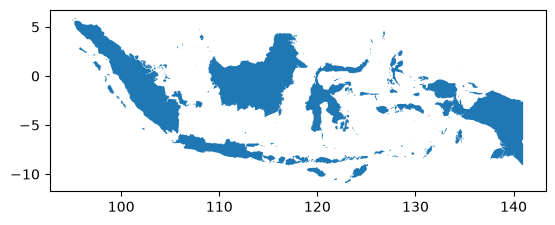

In [22]:
country_shape = world.geometry.iloc[0]

# create a plot of the specific country
plt.figure(figsize=(10, 10))

# plot the country shape
gpd.GeoSeries([country_shape]).plot()

In [23]:
world.head()

,featurecla,scalerank,LABELRANK,SOVEREIGNT,SOV_A3,ADM0_DIF,LEVEL,TYPE,TLC,ADMIN,...,FCLASS_TR,FCLASS_ID,FCLASS_PL,FCLASS_GR,FCLASS_IT,FCLASS_NL,FCLASS_SE,FCLASS_BD,FCLASS_UA,geometry
0,Admin-0 country,0,2,Indonesia,IDN,0,2,Sovereign country,1,Indonesia,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((117.70361 4.16341, 117.70361 4..."
1,Admin-0 country,0,3,Malaysia,MYS,0,2,Sovereign country,1,Malaysia,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((117.70361 4.16341, 117.69711 4..."
2,Admin-0 country,0,2,Chile,CHL,0,2,Sovereign country,1,Chile,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((-69.51009 -17.50659, -69.50611..."
3,Admin-0 country,0,3,Bolivia,BOL,0,2,Sovereign country,1,Bolivia,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((-69.51009 -17.50659, -69.51009 -17.5..."
4,Admin-0 country,0,2,Peru,PER,0,2,Sovereign country,1,Peru,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((-69.51009 -17.50659, -69.63832..."


<Axes: >

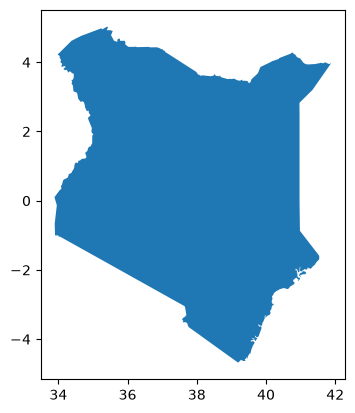

In [26]:
kenya = world[world['ADMIN'] == 'Kenya']
kenya.plot()

In [27]:
kenya

,featurecla,scalerank,LABELRANK,SOVEREIGNT,SOV_A3,ADM0_DIF,LEVEL,TYPE,TLC,ADMIN,...,FCLASS_TR,FCLASS_ID,FCLASS_PL,FCLASS_GR,FCLASS_IT,FCLASS_NL,FCLASS_SE,FCLASS_BD,FCLASS_UA,geometry
16,Admin-0 country,0,2,Kenya,KEN,0,2,Sovereign country,1,Kenya,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((35.70585 4.61945, 35.70594 4.6..."


<Axes: >

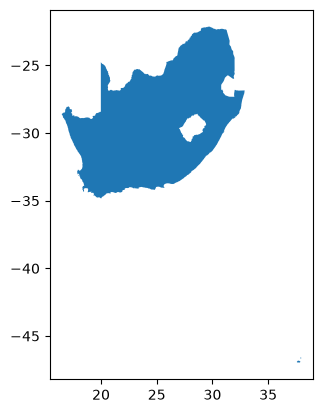

In [28]:
south_africa = world[world['ADMIN'] == 'South Africa']
south_africa.plot()

<Axes: >

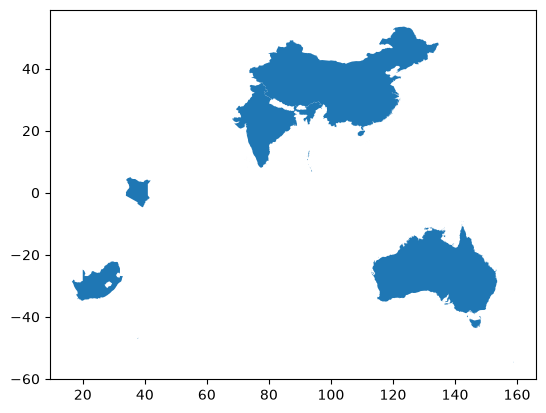

In [29]:
# unique names for the countries
world['ADMIN'].unique()
# create a list of the countries
countries = ['Kenya', 'South Africa', 'United States', 'China', 'India', 'Australia']
# filter the data to only include the countries in the list
world_countries = world[world['ADMIN'].isin(countries)]
world_countries.plot()
# create a scatter plot of the countries

In [30]:
world.geometry.extract_unique_points()

0      MULTIPOINT ((117.70361 4.16341), (117.70361 4....
1      MULTIPOINT ((117.70361 4.16341), (117.69711 4....
2      MULTIPOINT ((-69.51009 -17.50659), (-69.50611 ...
3      MULTIPOINT ((-69.51009 -17.50659), (-69.51009 ...
4      MULTIPOINT ((-69.51009 -17.50659), (-69.63832 ...
                             ...                        
253    MULTIPOINT ((113.5586 22.16303), (113.56943 22...
254    MULTIPOINT ((123.59702 -12.42832), (123.59775 ...
255    MULTIPOINT ((-79.98929 15.79495), (-79.98782 1...
256    MULTIPOINT ((-78.63707 15.86209), (-78.64041 1...
257    MULTIPOINT ((117.75389 15.15437), (117.75569 1...
Length: 258, dtype: geometry

In [31]:
world.geom_type.value_counts()

MultiPolygon    151
Polygon         107
Name: count, dtype: int64

## Customizing the World Plot

<Axes: >

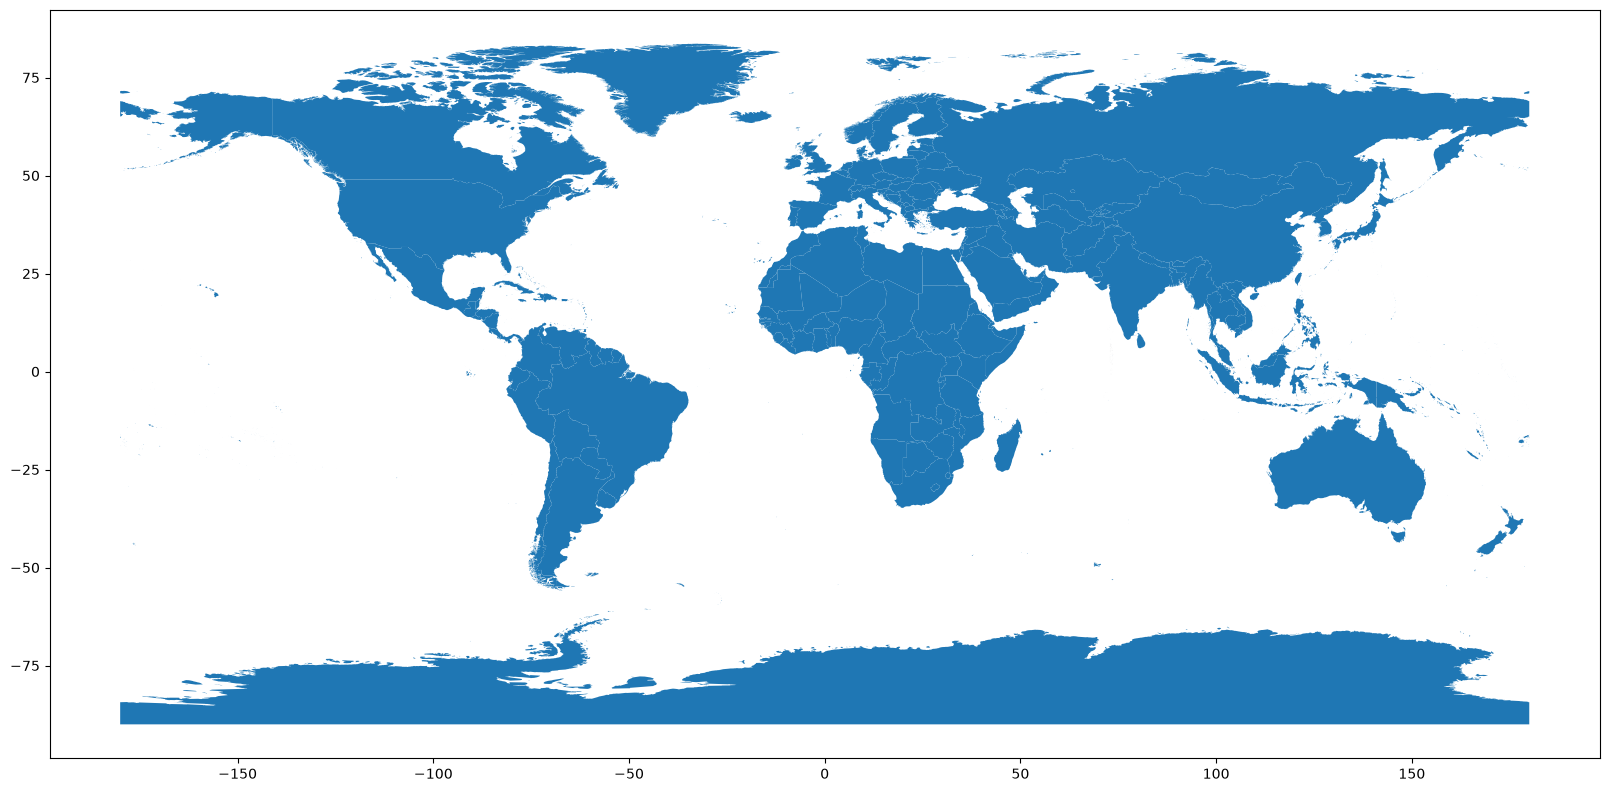

In [34]:
world.plot(figsize=(20, 10))

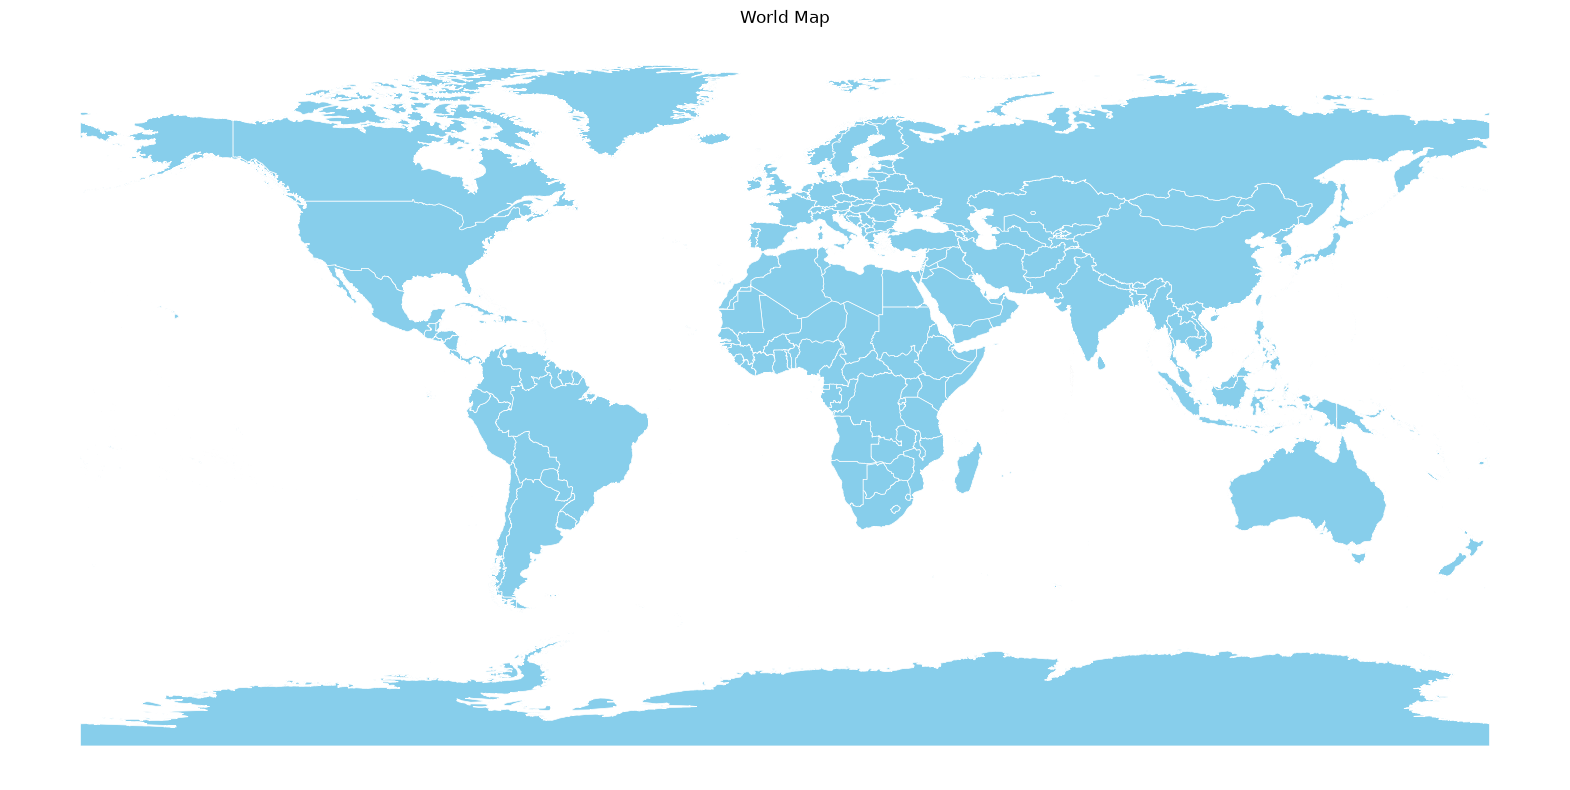

In [46]:
ax = world.plot(
    figsize=(20, 10),
    color='skyblue',
    edgecolor='white',
    linewidth=0.5
)
ax.set_title('World Map')
ax.axis('off')
plt.show()

## Mapping and plotting tools

In [48]:
!pip3 install geodatasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [geodatasets]

[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: pip3 install --upgrade pip


In [49]:
import geodatasets as gd

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [54]:
gd.data

{'geoda': {'airbnb': {'url': 'https://geodacenter.github.io/data-and-lab//data/airbnb.zip',
   'license': 'NA',
   'attribution': 'Center for Spatial Data Science, University of Chicago',
   'name': 'geoda.airbnb',
   'description': 'Airbnb rentals, socioeconomics, and crime in Chicago',
   'geometry_type': 'Polygon',
   'nrows': 77,
   'ncols': 21,
   'details': 'https://geodacenter.github.io/data-and-lab//airbnb/',
   'hash': 'a2ab1e3f938226d287dd76cde18c00e2d3a260640dd826da7131827d9e76c824',
   'filename': 'airbnb.zip'},
  'atlanta': {'url': 'https://geodacenter.github.io/data-and-lab//data/atlanta_hom.zip',
   'license': 'NA',
   'attribution': 'Center for Spatial Data Science, University of Chicago',
   'name': 'geoda.atlanta',
   'description': 'Atlanta, GA region homicide counts and rates',
   'geometry_type': 'Polygon',
   'nrows': 90,
   'ncols': 24,
   'details': 'https://geodacenter.github.io/data-and-lab//atlanta_old/',
   'hash': 'a33a76e12168fe84361e60c88a9df4856730487305846c559715c89b1a2b5e09',
   'filename': 'atlanta_hom.zip',
   'members': ['atlanta_hom/atl_hom.geojson']},
  'cars': {'url': 'https://geodacenter.github.io/data-and-lab//data/Abandoned_Vehicles_Map.csv',
   'license': 'NA',
   'attribution': 'Center for Spatial Data Science, University of Chicago',
   'name': 'geoda.cars',
   'description': '2011 abandoned vehicles in Chicago (311 complaints).',
   'geometry_type': 'Point',
   'nrows': 137867,
   'ncols': 21,
   'details': 'https://geodacenter.github.io/data-and-lab//1-source-and-description/',
   'hash': '6a0b23bc7eda2dcf1af02d43ccf506b24ca8d8c6dc2fe86a2a1cc051b03aae9e',
   'filename': 'Abandoned_Vehicles_Map.csv'},
  'charleston1': {'url': 'https://geodacenter.github.io/data-and-lab//data/CharlestonMSA.zip',
   'license': 'NA',
   'attribution': 'Center for Spatial Data Science, University of Chicago',
   'name': 'geoda.charleston1',
   'description': '2000 Census Tract Data for Charleston, SC MSA and counties',
   'geometry_type': 'Polygon',
   'nrows': 117,
   'ncols': 31,
   'details': 'https://geodacenter.github.io/data-and-lab//charleston-1_old/',
   'hash': '4a4fa9c8dd4231ae0b2f12f24895b8336bcab0c28c48653a967cffe011f63a7c',
   'filename': 'CharlestonMSA.zip',
   'members': ['CharlestonMSA/sc_final_census2.gpkg']},
  'charleston2': {'url': 'https://geodacenter.github.io/data-and-lab//data/CharlestonMSA2.zip',
   'license': 'NA',
   'attribution': 'Center for Spatial Data Science, University of Chicago',
   'name': 'geoda.charleston2',
   'description': '1998 and 2001 Zip Code Business Patterns (Census Bureau) for Charleston, SC MSA',
   'geometry_type': 'Polygon',
   'nrows': 42,
   'ncols': 60,
   'details': 'https://geodacenter.github.io/data-and-lab//charleston2/',
   'hash': '056d5d6e236b5bd95f5aee26c77bbe7d61bd07db5aaf72866c2f545205c1d8d7',
   'filename': 'CharlestonMSA2.zip',
   'members': ['CharlestonMSA2/CharlestonMSA2.gpkg']},
  'chicago_health': {'url': 'https://geodacenter.github.io/data-and-lab//data/comarea.zip',
   'license': 'NA',
   'attribution': 'Center for Spatial Data Science, University of Chicago',
   'name': 'geoda.chicago_health',
   'description': 'Chicago Health + Socio-Economics',
   'geometry_type': 'Polygon',
   'nrows': 77,
   'ncols': 87,
   'details': 'https://geodacenter.github.io/data-and-lab//comarea_vars/',
   'hash': '4e872adb552786eae2fcd745524696e5e4cd33cc9a6c032471c0e75328871401',
   'filename': 'comarea.zip'},
  'chicago_commpop': {'url': 'https://geodacenter.github.io/data-and-lab//data/chicago_commpop.zip',
   'license': 'NA',
   'attribution': 'Center for Spatial Data Science, University of Chicago',
   'name': 'geoda.chicago_commpop',
   'description': 'Chicago Community Area Population Percent Change for 2000 and 2010',
   'geometry_type': 'Polygon',
   'nrows': 77,
   'ncols': 9,
   'details': 'https://geodacenter.github.io/data-and-lab//commpop/',
   'hash': '1dbebb50c8ea47e2279ea819ef64ba793bdee2b88e4716bd6c6ec0e0d8e0e05b',
   'filename': 'c

In [61]:
airbnb = gpd.read_file(gd.get_path('geoda.airbnb'))
airbnb.head()


,community,shape_area,shape_len,AREAID,response_r,accept_r,rev_rating,price_pp,room_type,num_spots,...,crowded,dependency,without_hs,unemployed,income_pc,harship_in,num_crimes,num_theft,population,geometry
0,DOUGLAS,46004621.1581,31027.0545098,35,98.771429,94.514286,87.777778,78.157895,1.789474,38,...,1.8,30.7,14.3,18.2,23791,47,5013,1241,18238,"POLYGON ((-87.60914 41.84469, -87.60915 41.844..."
1,OAKLAND,16913961.0408,19565.5061533,36,99.200000,90.105263,88.812500,53.775000,1.850000,20,...,1.3,40.4,18.4,28.7,19252,78,1306,311,5918,"POLYGON ((-87.59215 41.81693, -87.59231 41.816..."
2,FULLER PARK,19916704.8692,NaN,37,68.000000,NaN,91.750000,84.000000,1.833333,6,...,3.2,44.9,26.6,33.9,10432,97,1764,383,2876,"POLYGON ((-87.6288 41.80189, -87.62879 41.8017..."
3,GRAND BOULEVARD,48492503.1554,28196.8371573,38,94.037037,83.615385,92.750000,119.533333,1.533333,30,...,3.3,39.5,15.9,24.3,23472,57,6416,1428,21929,"POLYGON ((-87.60671 41.81681, -87.6067 41.8165..."
4,KENWOOD,29071741.9283,23325.1679062,39,92.542857,88.142857,90.656250,77.991453,1.615385,39,...,2.4,35.4,11.3,15.7,35911,26,2713,654,17841,"POLYGON ((-87.59215 41.81693, -87.59215 41.816..."


In [80]:
!pip3 install mapclassify

  Using cached scikit_learn-1.9.0-cp314-cp314-macosx_12_0_arm64.whl.metadata (11 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 882.2/882.2 kB 2.0 MB/s  0:00:00m 1.6 MB/s eta 0:00:01
Using cached scikit_learn-1.9.0-cp314-cp314-macosx_12_0_arm64.whl (8.2 MB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [mapclassify] 1/3 [scikit-learn]

[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: pip3 install --upgrade pip


In [81]:
import mapclassify as mc

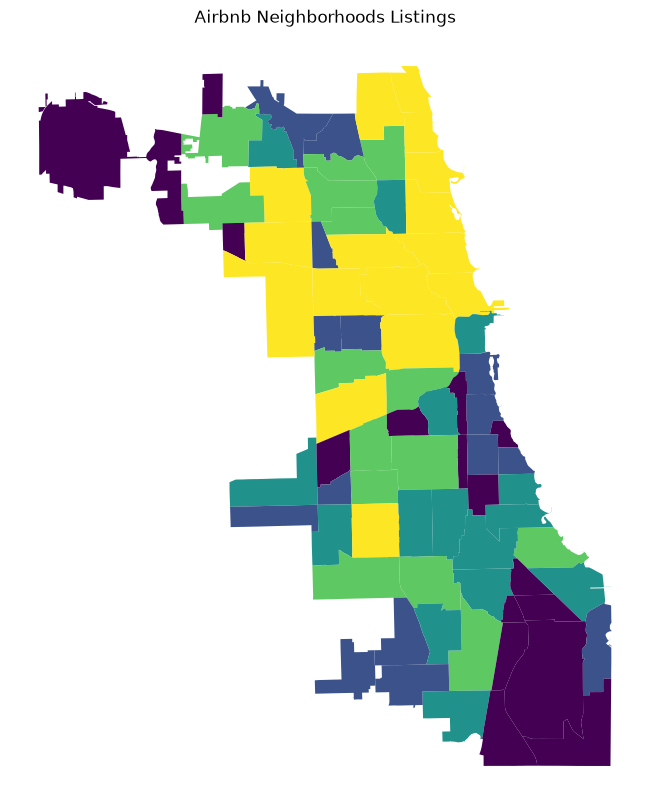

In [84]:
ax = airbnb.plot(
    figsize=(20, 10), 
    column='population', 
    # legend=True,
    # legend_kwds={'label': 'Population by Neighborhood'},
    # cmap='inferno', 
    # edgecolor='white', 
    # linewidth=0.5,
    scheme='quantiles'
)
ax.set_title('Airbnb Neighborhoods Listings')
ax.axis('off')
plt.show()
